In [892]:
# Prueba de ABC interna
# from functools import partial
# import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import statsmodels as sm
# import statsmodels.api as sm
# import copy
from scipy.spatial.distance import pdist, squareform
from scipy.stats import gamma, norm, multivariate_normal
from scipy.special import logit, expit
# from scipy.special import gamma, factorial
from timeit import default_timer as timer
from sklearn.preprocessing import MinMaxScaler
# importing datetime module
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

In [920]:
np.random.seed(10)
aleatorio = np.random.normal(loc=-3, scale = 4.9, size=1000) * np.random.binomial(n=1, p=0.15, size=1000)
print(aleatorio.mean())

-0.4578106611387208


In [921]:
n_sizeABC = 5000

previas_media = np.random.uniform(low = -5, high = 5, size = n_sizeABC)
previas_sd = np.random.uniform(low = 0, high = 5, size = n_sizeABC)
previas_exp = np.random.uniform(low = 0, high = 1, size = n_sizeABC)

simulaciones = np.random.normal(loc = previas_media, scale = previas_sd, size = (1000,n_sizeABC)) * np.random.binomial(n=1, p = previas_exp, size= (1000,n_sizeABC))
simulaciones = simulaciones.round(5)

In [922]:
error = ( (simulaciones - aleatorio[:, None]) ** 2 ).mean(axis=0)
print(error.mean())
print(min(error))

12.515996537397024
4.010900498370646


In [896]:
# ponderador_penalizacion = error.mean() * 10
# error = error + ponderador_penalizacion * abs(np.sum(simulaciones == 0, axis=0) - np.sum(aleatorio[:,None] == 0, axis=0)) / np.sum(aleatorio[:,None] == 0, axis=0)

In [923]:
error = np.array([wasserstein_distance(aleatorio, simulaciones[:,i]) for i in range(simulaciones.shape[1])])

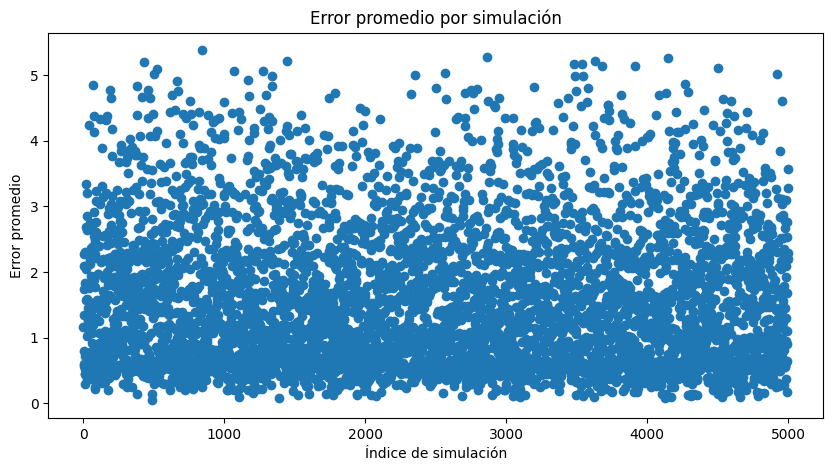

In [924]:
plt.figure(figsize=(10,5))
plt.scatter(range(len(error)), error)
plt.xlabel("Índice de simulación")
plt.ylabel("Error promedio")
plt.title("Error promedio por simulación")
plt.show()

In [925]:
idx_mejores = np.argsort(error)[:int(n_sizeABC*0.01)]

idx_mejores

array([ 484, 4124, 1387, 3095, 3623, 4661, 4167, 4534, 1103, 4313, 4787,
       2079, 2687, 3543, 3048, 4288, 2043, 1944, 3131, 2900, 3063, 3498,
       1521, 1770, 4353,  490, 4105,  378, 1603, 4331, 1722, 4501, 4133,
       4314, 1939, 2552, 4830, 4804, 3526, 1207, 3931, 4644, 3586, 4553,
       3906, 4995, 2111, 4781, 3753, 4577], dtype=int64)

In [926]:
df_resultados = pd.DataFrame({
    "simulacion": np.arange(len(error)),
    "error": error,
    "previa_media": previas_media,
    "previa_sd": previas_sd,
    "previa_exp": previas_exp
})

df_resultados

,simulacion,error,previa_media,previa_sd,previa_exp
0,0,1.164321,-0.827668,1.506012,0.930653
1,1,0.569222,1.077088,2.376846,0.080800
2,2,1.749379,-4.311975,1.809746,0.487885
3,3,2.269553,-2.213978,3.281451,0.875763
4,4,2.085031,3.933098,3.055664,0.446218
...,...,...,...,...,...
4995,4995,0.176968,-3.741706,2.960386,0.126428
4996,4996,3.278056,-4.842601,4.510515,0.772318
4997,4997,2.195894,4.767917,2.376241,0.371212
4998,4998,2.285462,3.875901,4.326859,0.492612


In [927]:
top5 = df_resultados.loc[idx_mejores].sort_values("error")

top5

,simulacion,error,previa_media,previa_sd,previa_exp
484,484,0.049540,-3.365573,4.261772,0.143934
4124,4124,0.082187,-4.593156,4.704307,0.113235
1387,1387,0.082190,-3.516948,3.888270,0.108963
3095,3095,0.092085,-2.895122,3.956933,0.137565
3623,3623,0.097974,-2.128643,3.580712,0.127927
4661,4661,0.099927,-2.234214,3.967705,0.196466
4167,4167,0.100417,-4.103558,4.757093,0.128347
4534,4534,0.105007,-2.542451,3.905943,0.160694
1103,1103,0.105104,-4.470170,4.420102,0.118982
4313,4313,0.106204,-3.848422,3.632131,0.127584


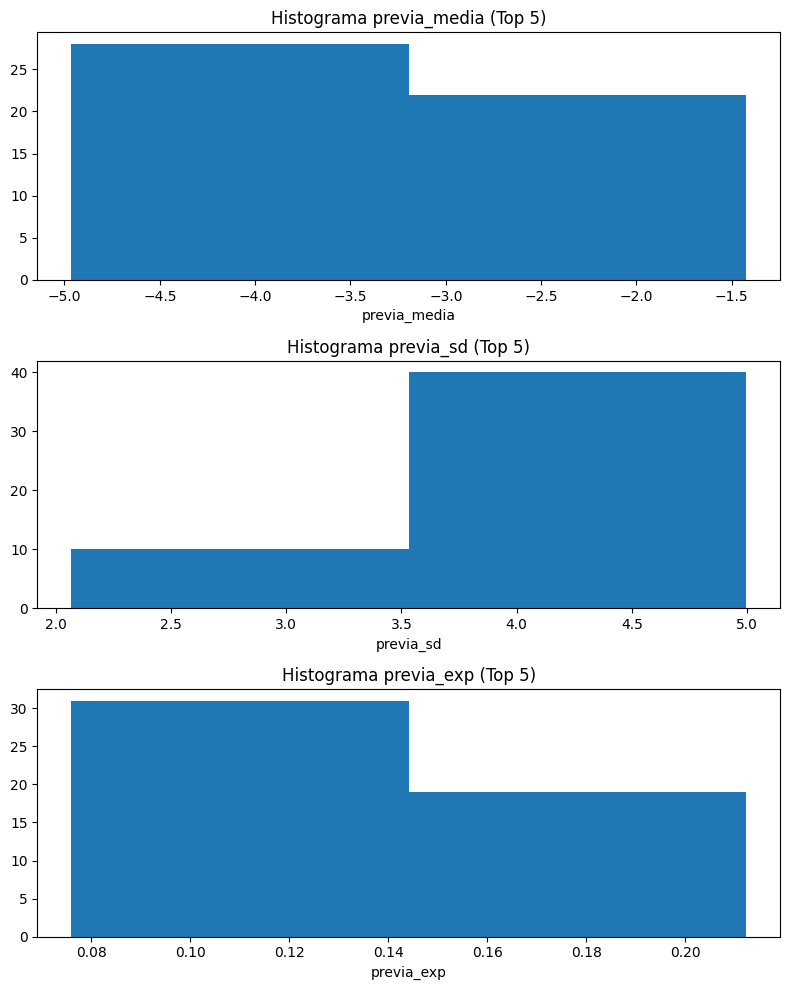

In [928]:
columnas = ["previa_media", "previa_sd", "previa_exp"]

fig, axs = plt.subplots(len(columnas), 1, figsize=(8,10))

for ax, col in zip(axs, columnas):
    ax.hist(top5[col], bins = int(n_sizeABC*0.01/20))
    ax.set_title(f"Histograma {col} (Top 5)")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

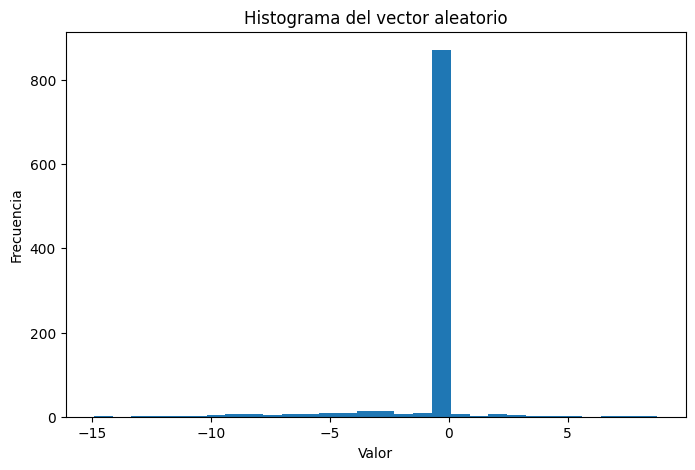

In [929]:
plt.figure(figsize=(8,5))
plt.hist(aleatorio, bins=30)
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.title("Histograma del vector aleatorio")
plt.show()

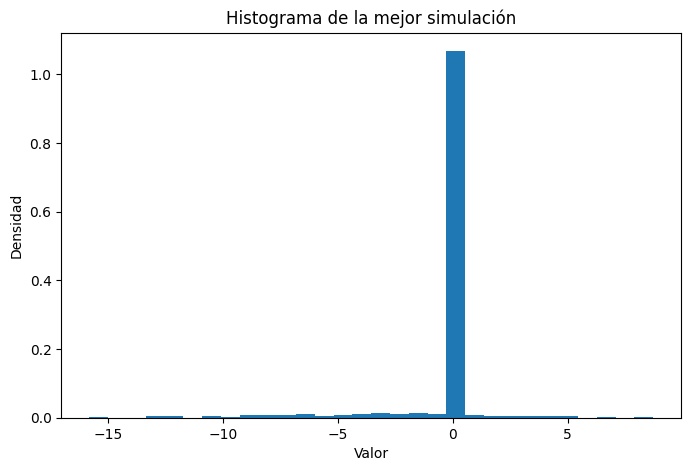

In [930]:
mejor_idx = np.argmin(error)
mejor_simulacion = simulaciones[:, mejor_idx]

plt.figure(figsize=(8,5))
plt.hist(mejor_simulacion, bins=30, density=True)
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.title("Histograma de la mejor simulación")
plt.show()

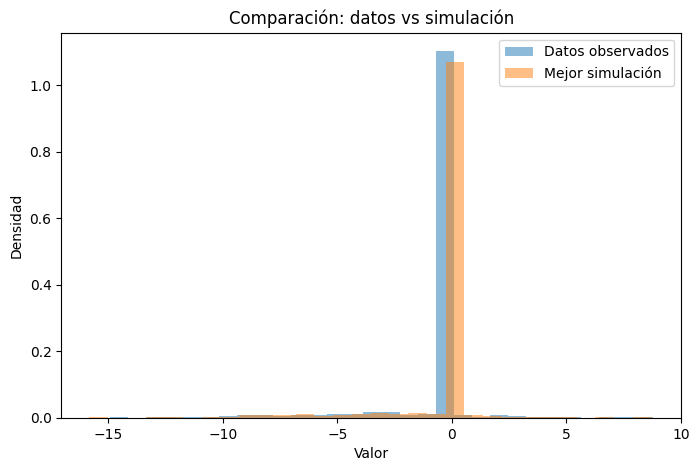

Índice simulación: 484
Error: 0.04953987005751543
previa_media: -3.3655734487838807
previa_sd: 4.261772374335989
previa_exp: 0.14393440873187202


In [931]:
plt.figure(figsize=(8,5))

plt.hist(aleatorio, bins=30, density=True, alpha=0.5, label="Datos observados")
plt.hist(mejor_simulacion, bins=30, density=True, alpha=0.5, label="Mejor simulación")

plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.title("Comparación: datos vs simulación")
plt.legend()

plt.show()

print("Índice simulación:", mejor_idx)
print("Error:", error[mejor_idx])
print("previa_media:", previas_media[mejor_idx])
print("previa_sd:", previas_sd[mejor_idx])
print("previa_exp:", previas_exp[mejor_idx])

In [919]:
print( top5["previa_media"].mean() )
print( top5["previa_sd"].mean() )
print( top5["previa_exp"].mean() )

-2.7681403081645537
1.0398093395654118
0.16817424142710483


In [891]:
np.abs( np.random.normal(0,1,2000) - np.random.normal(0,1,2000) ).mean()

1.1244518248206452

In [830]:
( np.random.normal(0,1,2000) - np.random.normal(0,1,2000) ).mean()

0.003288450750027737